In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
import vrplib
from tensordict import TensorDict

from rl4co.envs import CVRPEnv
from rl4co.models.zoo.am import AttentionModelPolicy
from rl4co.models.rl import REINFORCE
from rl4co.utils.trainer import RL4COTrainer
from pathlib import Path

from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RL4CO env based on TorchRL
env = CVRPEnv(generator_params={'num_loc': 50})

# Policy: neural network, in this case with encoder-decoder architecture
policy = AttentionModelPolicy(env_name=env.name).to(device)

# RL Model: REINFORCE and greedy rollout baseline
model = REINFORCE(env, 
                    policy,
                    baseline="rollout",
                    batch_size=512,
                    train_data_size=100_000,
                    val_data_size=10_000,
                    optimizer_kwargs={"lr": 1e-4},
                    ) 

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


In [3]:
# Utils function: we will normalize the coordinates of the VRP instances
def normalize_coord(coord:torch.Tensor) -> torch.Tensor:
    x, y = coord[:, 0], coord[:, 1]
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    x_scaled = (x - x_min) / (x_max - x_min) 
    y_scaled = (y - y_min) / (y_max - y_min)
    coord_scaled = torch.stack([x_scaled, y_scaled], dim=1)
    return coord_scaled 

def vrplib_to_td(problem, normalize=True):
    coords = torch.tensor(problem['node_coord']).float()
    coords_norm = normalize_coord(coords) if normalize else coords
    demand = torch.tensor(problem['demand'][1:]).float()
    capacity = problem['capacity']
    n = coords.shape[0]
    td = TensorDict({
        'depot': coords_norm[0,:],
        'locs': coords_norm[1:,:],
        'demand': demand / capacity, # normalized demand
        'capacity': capacity, # original capacity, not needed for inference
    })
    td = td[None] # add batch dimension, in this case just 1
    return td

In [11]:
datasets_path = Path("../../datasets")
instances = [f.stem for f in (datasets_path).glob("*.vrp")]

# Test Untrained

In [12]:
tds, actions = [], []
for instance in instances:
    # Inference
    print(f'Processing instance: {instance}')
    problem = vrplib.read_instance(os.path.join(datasets_path, instance+'.vrp'))
    td_reset = env.reset(vrplib_to_td(problem).to(device))
    with torch.inference_mode():
        out = policy(td_reset.clone(), env, decode_type="sampling", num_samples=128, select_best=True)
        unnormalized_td = env.reset(vrplib_to_td(problem, normalize=False).to(device))
        cost = -env.get_reward(unnormalized_td, out["actions"]).int().item() # unnormalized cost
        
    # Load the optimal cost
    solution = vrplib.read_solution(os.path.join(datasets_path, instance+'.sol'))
    optimal_cost = solution['cost']

    tds.append(td_reset)
    actions.append(out["actions"])
    
    # Calculate the gap and print
    gap = (cost - optimal_cost) / optimal_cost
    print(f'Problem: {instance:<15} Cost: {cost:<8} BKS: {optimal_cost:<8}\t Gap: {gap:.2%}')

Processing instance: Golden_1
Problem: Golden_1        Cost: 25599    BKS: 5623.47 	 Gap: 355.22%
Processing instance: F-n72-k4
Problem: F-n72-k4        Cost: 1062     BKS: 237     	 Gap: 348.10%
Processing instance: P-n16-k8
Problem: P-n16-k8        Cost: 493      BKS: 450     	 Gap: 9.56%
Processing instance: tai75a
Problem: tai75a          Cost: 4657     BKS: 1618.36 	 Gap: 187.76%
Processing instance: X-n101-k25
Problem: X-n101-k25      Cost: 53714    BKS: 27591   	 Gap: 94.68%
Processing instance: ORTEC-n242-k12
Problem: ORTEC-n242-k12  Cost: 89048    BKS: 123750  	 Gap: -28.04%
Processing instance: Li_21
Problem: Li_21           Cost: 120937   BKS: 16212.82548	 Gap: 645.93%
Processing instance: A-n32-k5
Problem: A-n32-k5        Cost: 1546     BKS: 784     	 Gap: 97.19%
Processing instance: M-n101-k10
Problem: M-n101-k10      Cost: 3095     BKS: 820     	 Gap: 277.44%
Processing instance: CMT6
Problem: CMT6            Cost: 1331     BKS: 555.43  	 Gap: 139.63%
Processing instance:

<Axes: >

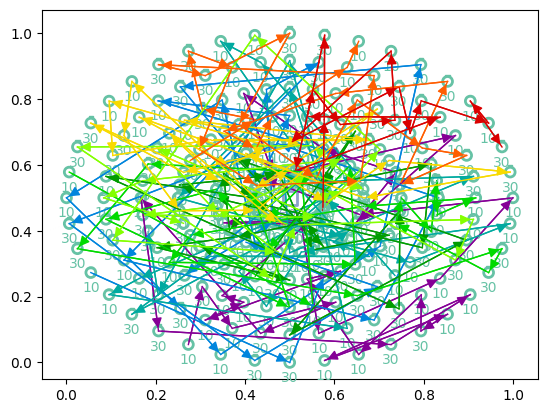

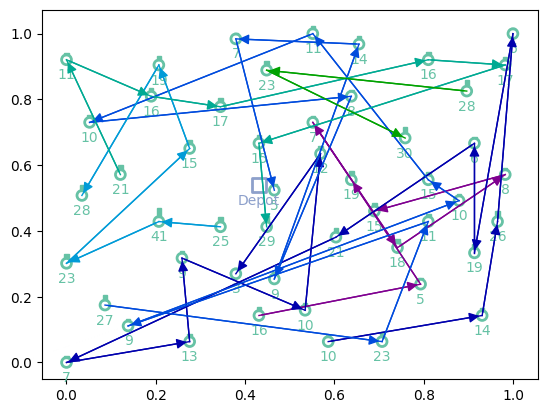

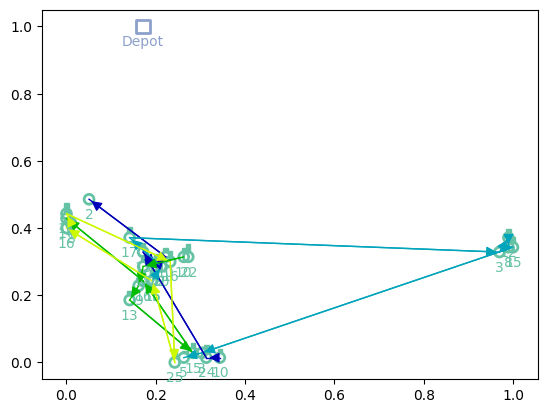

In [13]:
# Plot some instances
env.render(tds[0], actions[0].cpu())
env.render(tds[-2], actions[-2].cpu())
env.render(tds[-1], actions[-1].cpu())


# TRain

In [14]:
trainer = RL4COTrainer(
    max_epochs=3,
    accelerator="gpu",
    devices=1,
    logger=None,
)

trainer.fit(model)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [li

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ CVRPEnv              │      0 │ train │     0 │
│ 1 │ policy   │ AttentionModelPolicy │  694 K │ train │     0 │
│ 2 │ baseline │ WarmupBaseline       │  694 K │ train │     0 │
└───┴──────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 73                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/ut
ilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/lo
ops/fit_loop.py:534: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior
during training. If this is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=3` reached.


# Test trained

In [15]:
policy = model.policy.to(device).eval() # trained policy

tds, actions = [], []
for instance in instances:
    # Inference
    problem = vrplib.read_instance(os.path.join(datasets_path, instance+'.vrp'))
    td_reset = env.reset(vrplib_to_td(problem).to(device))
    with torch.inference_mode():
        out = policy(td_reset.clone(), env, decode_type="sampling", num_samples=128, select_best=True)
        unnormalized_td = env.reset(vrplib_to_td(problem, normalize=False).to(device))
        cost = -env.get_reward(unnormalized_td, out["actions"]).int().item() # unnormalized cost
        
    # Load the optimal cost
    solution = vrplib.read_solution(os.path.join(datasets_path, instance+'.sol'))
    optimal_cost = solution['cost']

    tds.append(td_reset)
    actions.append(out["actions"])
    
    # Calculate the gap and print
    gap = (cost - optimal_cost) / optimal_cost
    print(f'Problem: {instance:<15} Cost: {cost:<8} BKS: {optimal_cost:<8}\t Gap: {gap:.2%}')

Problem: Golden_1        Cost: 9687     BKS: 5623.47 	 Gap: 72.26%
Problem: F-n72-k4        Cost: 316      BKS: 237     	 Gap: 33.33%
Problem: P-n16-k8        Cost: 473      BKS: 450     	 Gap: 5.11%
Problem: tai75a          Cost: 2027     BKS: 1618.36 	 Gap: 25.25%
Problem: X-n101-k25      Cost: 31206    BKS: 27591   	 Gap: 13.10%
Problem: ORTEC-n242-k12  Cost: 30939    BKS: 123750  	 Gap: -75.00%
Problem: Li_21           Cost: 57429    BKS: 16212.82548	 Gap: 254.22%
Problem: A-n32-k5        Cost: 833      BKS: 784     	 Gap: 6.25%
Problem: M-n101-k10      Cost: 1113     BKS: 820     	 Gap: 35.73%
Problem: CMT6            Cost: 620      BKS: 555.43  	 Gap: 11.63%
Problem: B-n31-k5        Cost: 717      BKS: 672     	 Gap: 6.70%
